<a href="https://colab.research.google.com/github/sarahbraia/statistics-with-python/blob/main/1_T_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Distribuição T Student

In [6]:
# Importação da função para fazer o teste
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Média de salário dos cientistas de dados = R$ 75,00 por hora
Amostra com 9 funcionários e desvio padrão = 10

#### Qual a probabilidade de selecionar um cientista de dados e o salário ser menor que R$ 80 por hora

Estatística t: 1.50
P(X < 80): 0.914 ou 91.4%


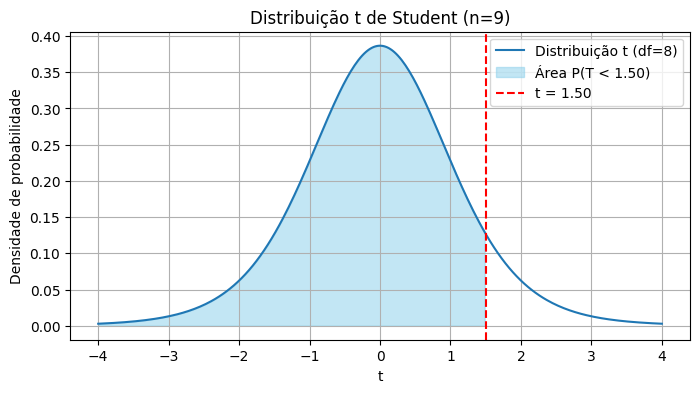

In [7]:
#como estamos usando uma amostra pequena (n < 30) e não conhecemos o desvio padrão populacional,
#usamos a distribuição t de Student ao invés da normal padrão.
#cdf olha a esquerda da distribuição

# Parâmetros do problema
media = 75
desvio_padrao = 10
n = 9
valor_x = 80

# Erro padrão da média (SEM)
sem = desvio_padrao / np.sqrt(n)

# Graus de liberdade
df = n - 1

# Estatística t
t_calc = (valor_x - media) / sem

# Probabilidade acumulada P(T < t)
p_valor = stats.t.cdf(t_calc, df)

print(f'Estatística t: {t_calc:.2f}')
print(f'P(X < 80): {p_valor:.3f} ou {p_valor*100:.1f}%')

# Geração da curva t de Student
# O intervalo de -4 a 4 é usado porque:Quase toda a probabilidade (mais de 99,99%) da distribuição t com df = 8 está nesse intervalo.
#alores de t mais extremos (menores que -4 ou maiores que 4) são extremamente improváveis.
x = np.linspace(-4, 4, 300)
y = stats.t.pdf(x, df)

# Plot
plt.figure(figsize=(8, 4)) #tamanho do gráfico
plt.plot(x, y, label='Distribuição t (df=8)')
#Sombreia a área sob a curva até o valor de t calculado
plt.fill_between(x, y, 0, where=(x <= t_calc), color='skyblue', alpha=0.5, label=f'Área P(T < {t_calc:.2f})')
plt.axvline(t_calc, color='red', linestyle='--', label=f't = {t_calc:.2f}')
plt.title('Distribuição t de Student (n=9)')
plt.xlabel('t')
plt.ylabel('Densidade de probabilidade')
plt.legend()
#Adiciona uma grade (linhas de referência horizontais/verticais no fundo)
plt.grid(True)
plt.show()


#### Qual a probabilidade do salário ser maior do que 80?

Estatística t: 1.50
P(X > 80): 0.086 ou 8.6%


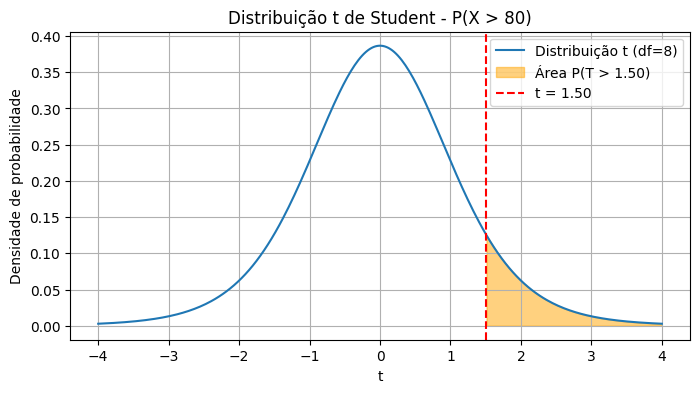

In [12]:

# Parâmetros do problema
media = 75
desvio_padrao = 10
n = 9
valor_x = 80

# Erro padrão da média (SEM)
sem = desvio_padrao / np.sqrt(n)

# Graus de liberdade
df = n - 1

# Estatística t
t_calc = (valor_x - media) / sem

# Probabilidade de X > 80
p_maior = 1 - stats.t.cdf(t_calc, df)

print(f'Estatística t: {t_calc:.2f}')
print(f'P(X > 80): {p_maior:.3f} ou {p_maior*100:.1f}%')

# Geração da curva t de Student
# O intervalo de -4 a 4 é usado porque:Quase toda a probabilidade (mais de 99,99%) da distribuição t com df = 8 está nesse intervalo.
#alores de t mais extremos (menores que -4 ou maiores que 4) são extremamente improváveis.
x = np.linspace(-4, 4, 300)
y = stats.t.pdf(x, df)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='Distribuição t (df=8)')
plt.fill_between(x, y, 0, where=(x > t_calc), color='orange', alpha=0.5, label=f'Área P(T > {t_calc:.2f})')
plt.axvline(t_calc, color='red', linestyle='--', label=f't = {t_calc:.2f}')
plt.title('Distribuição t de Student - P(X > 80)')
plt.xlabel('t')
plt.ylabel('Densidade de probabilidade')
plt.legend()
plt.grid(True)
plt.show()

#### Somatório da execução dos dois códigos acima (lado esquerdo + lado direito da distribuição)

In [17]:
# Probabilidades acumuladas
p_menor = stats.t.cdf(t_calc, df)         # P(X < 80)
p_maior = 1 - p_menor                     # P(X > 80)
p_total = p_menor + p_maior               # Deve ser 1

print(f'Estatística t: {t_calc:.2f}')
print(f'P(X < 80): {p_menor:.3f} ou {p_menor*100:.1f}%')
print(f'P(X > 80): {p_maior:.3f} ou {p_maior*100:.1f}%')
print(f'Soma das probabilidades: {p_total:.3f} ou {p_total*100:.1f}%')


Estatística t: 1.50
P(X < 80): 0.914 ou 91.4%
P(X > 80): 0.086 ou 8.6%
Soma das probabilidades: 1.000 ou 100.0%


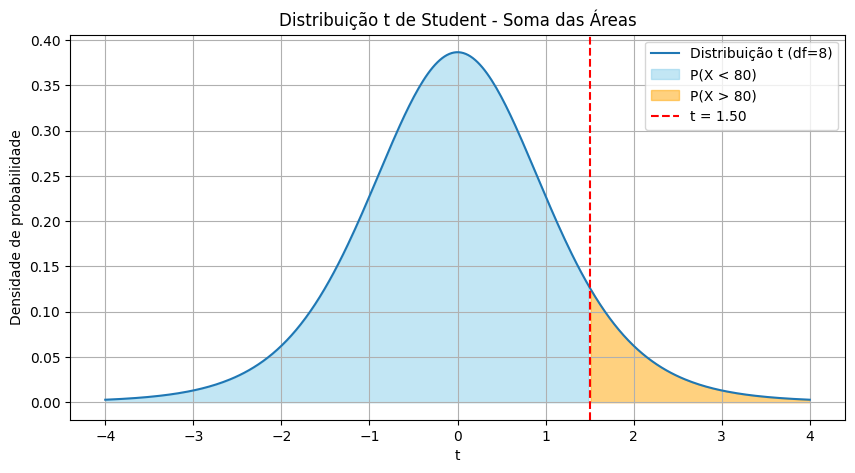

In [18]:
# Plotando os dois lados da curva
x = np.linspace(-4, 4, 300)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Distribuição t (df=8)')
plt.fill_between(x, y, 0, where=(x <= t_calc), color='skyblue', alpha=0.5, label='P(X < 80)')
plt.fill_between(x, y, 0, where=(x > t_calc), color='orange', alpha=0.5, label='P(X > 80)')
plt.axvline(t_calc, color='red', linestyle='--', label=f't = {t_calc:.2f}')
plt.title('Distribuição t de Student - Soma das Áreas')
plt.xlabel('t')
plt.ylabel('Densidade de probabilidade')
plt.legend()
plt.grid(True)
plt.show()
